# Sampling Distribution And Standard Error

## Sampling Distribution
    A Sampling Distribution is the probability distribution of a sample statistic obtained by repeatedly selecting samples of the same size from a population.

    Instead of focusing on individual observations, a Sampling Distribution focuses on a statistic such as the sample mean, sample proportion, or sample variance.

    Every time a new sample is selected from the population, the calculated statistic may be slightly different.

### Sample VS Population Distribution
    A Population Distribution describes the distribution of individual observations in the population.
    
    A Sampling Distribution describes the distribution of a statistic calculated from many different samples.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

Employees = pd.DataFrame({

    "Employee_ID": range(1,1001),

    "Monthly_Salary": np.random.randint(

        25000,

        120001,

        1000

    )

})

Employees.head()

,Employee_ID,Monthly_Salary
0,1,40795
1,2,25860
2,3,101820
3,4,79886
4,5,31265


In [3]:
Employees.shape

(1000, 2)

In [4]:
population_mean = Employees["Monthly_Salary"].mean()

print(f"Population Mean : {population_mean:.2f}")

Population Mean : 72442.59


In [5]:
sample_1 = Employees.sample(n=100,random_state=10)

sample_2 = Employees.sample(n=100,random_state=42)

sample_3 = Employees.sample(n=100,random_state=35)

  

In [6]:
comparison = pd.DataFrame(
        { 
            "Sample":["Sample 1","Sample 2","Sample 3"],

            "Sample Mean":[

                sample_1["Monthly_Salary"].mean(),

                sample_2["Monthly_Salary"].mean(),

                sample_3["Monthly_Salary"].mean()
        ]

})

comparison

,Sample,Sample Mean
0,Sample 1,69175.87
1,Sample 2,66304.12
2,Sample 3,72785.43


In [7]:
comparison.loc[len(comparison)] = ["Population",
                                    population_mean
                                  ]
comparison

,Sample,Sample Mean
0,Sample 1,69175.870
1,Sample 2,66304.120
2,Sample 3,72785.430
3,Population,72442.588


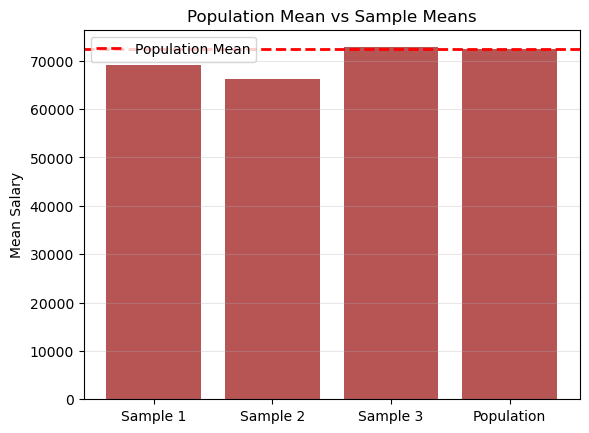

In [21]:
plt.bar(
    comparison["Sample"],
    comparison["Sample Mean"],
    color='brown',
    alpha=0.8
)

plt.axhline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"

)

plt.title("Population Mean vs Sample Means")

plt.ylabel("Mean Salary")

plt.legend()

plt.grid(axis="y",alpha=0.3)

plt.show()

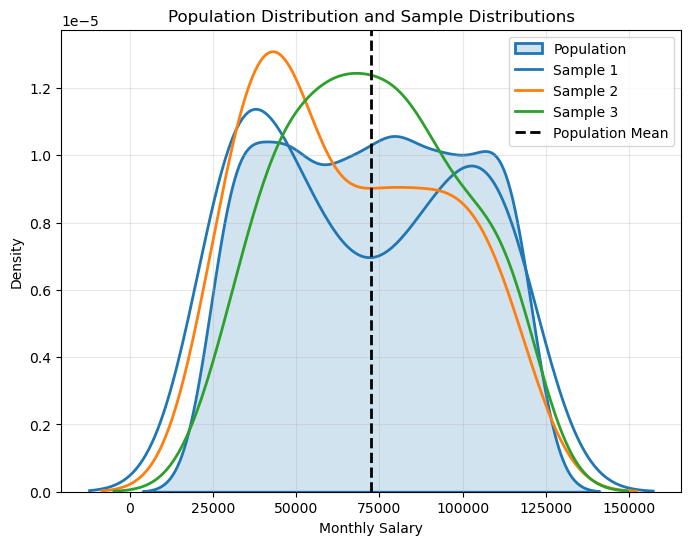

In [26]:
plt.figure(figsize=(8,6))
sns.kdeplot(

    Employees["Monthly_Salary"],

    label="Population",

    linewidth=2,

    fill=True,

    alpha=0.2

)

sns.kdeplot(

    sample_1["Monthly_Salary"],

    label="Sample 1",

    linewidth=2

)

sns.kdeplot(

    sample_2["Monthly_Salary"],

    label="Sample 2",

    linewidth=2

)

sns.kdeplot(

    sample_3["Monthly_Salary"],

    label="Sample 3",

    linewidth=2

)

plt.axvline(population_mean,color="black",linestyle="--",linewidth=2,label="Population Mean")

plt.title("Population Distribution and Sample Distributions")

plt.xlabel("Monthly Salary")

plt.ylabel("Density")

plt.legend(loc=1)

plt.grid(alpha=0.3)

plt.show()

### Sampling Distribution of the Mean

    The Sampling Distribution of the Mean is the distribution formed by the sample means obtained from repeatedly selecting random samples of the same size from a population.

    The process of creating a Sampling Distribution involves the following steps.
        
        1. Start with a population.
        2. Select a random sample of a fixed size.
        3. Calculate the sample mean.
        4. Repeat the process many times.
        5. Store every sample mean.
        6. Plot the distribution of these sample means.


In [45]:
sample_means = []

sample_size = 50

num_samples = 500

In [46]:
for i in range(num_samples):

    sample = Employees.sample( n=sample_size,replace=False)
    
    sample_means.append(sample["Monthly_Salary"].mean()
                       
)

In [47]:
sample_means = pd.DataFrame({
                              "Sample_Mean":sample_means
                             })

sample_means.head()

,Sample_Mean
0,77561.16
1,74047.58
2,77924.08
3,67624.26
4,70835.94


In [49]:
sample_means.describe().round(2)

,Sample_Mean
count,500.00
mean,72326.62
std,3849.33
min,59978.44
25%,69555.88
50%,72295.23
75%,74810.98
max,83086.06


### Population Mean vs Mean of Sample Means
    One of the most important properties of Sampling Distribution is that the average of all sample means is very close to the population mean.
$$
\bar{\bar{x}} \approx \mu
$$



In [50]:
population_mean = Employees["Monthly_Salary"].mean()

mean_of_sample_means = sample_means["Sample_Mean"].mean()

print(f"Population Mean      : {population_mean:.2f}")

print(f"Mean of Sample Means : {mean_of_sample_means:.2f}")

Population Mean      : 72442.59
Mean of Sample Means : 72326.62


In [51]:
comparison = pd.DataFrame({
            "Statistic":[
                            "Population Mean",
                            "Mean of Sample Means"

                        ],

            "Value":[
                             population_mean,
                            mean_of_sample_means
                    ]

                })

comparison

,Statistic,Value
0,Population Mean,72442.58800
1,Mean of Sample Means,72326.61516


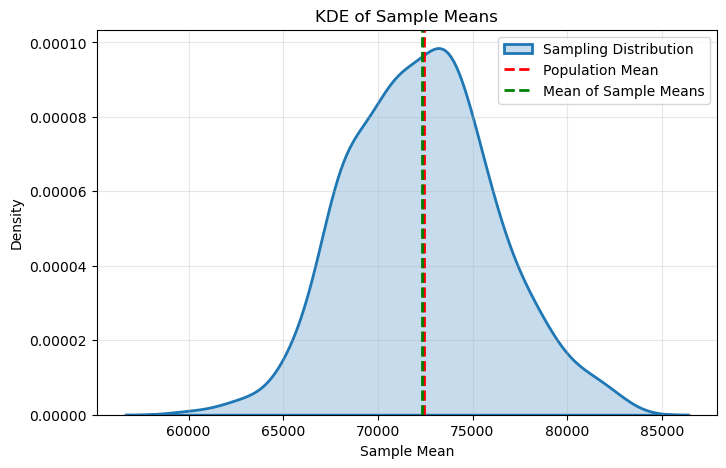

In [54]:
plt.figure(figsize=(8,5))

sns.kdeplot(
        sample_means["Sample_Mean"],
        fill=True,
        linewidth=2,
        label="Sampling Distribution"
        )

plt.axvline(population_mean,color="r",linestyle="--",linewidth=2,label="Population Mean")

plt.axvline(mean_of_sample_means,color="green",linestyle="--",linewidth=2,label="Mean of Sample Means")

plt.title("KDE of Sample Means")

plt.xlabel("Sample Mean")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Standard Error
    Standard Error is the standard deviation of the Sampling Distribution.

    It measures how much the sample statistic is expected to vary from one random sample to another.

    A smaller Standard Error means the sample mean is likely to be very close to the population mean.

    A larger Standard Error means the sample mean is likely to vary more from sample to sample.

### Formula
    The Standard Error of the Mean is calculated as

$$
SE=\frac{\sigma}{\sqrt{n}}
$$


### Standard Deviation vs Standard Error

| Standard Deviation | Standard Error |
|--------------------|----------------|
| Measures the spread of individual observations | Measures the spread of sample means |
| Describes the population or sample data | Describes the Sampling Distribution |
| Indicates data variability | Indicates estimate reliability |
| Does not necessarily decrease with larger sample sizes | Decreases as sample size increases |

In [55]:
population_std = Employees["Monthly_Salary"].std(ddof=0)

sample_size = 50

SE = population_std / np.sqrt(sample_size)

print(f"Population Standard Deviation : {population_std:.2f}")

print(f"Standard Error : {SE:.2f}")

Population Standard Deviation : 28151.60
Standard Error : 3981.24


### Standard Error Decreases As Sample Size Increases

In [58]:
sample_sizes = [30,50,100,200,500]

SE_values = []

for n in sample_sizes:
    se = population_std / np.sqrt(n)
    SE_values.append(se)

SE_df = pd.DataFrame({ "Sample Size":sample_sizes,"Standard Error":SE_values })

SE_df.round(2)

,Sample Size,Standard Error
0,30,5139.75
1,50,3981.24
2,100,2815.16
3,200,1990.62
4,500,1258.98


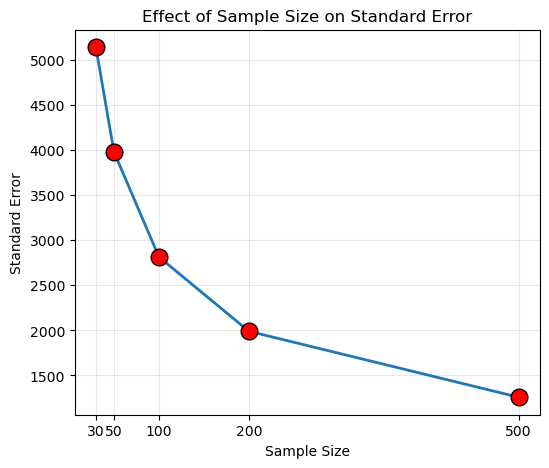

In [68]:
plt.figure(figsize=(6,5))

plt.plot(
    SE_df["Sample Size"],
    SE_df["Standard Error"],
    marker="o",
    mfc='r',
    ms=12,
    mec='black',
    linewidth=2
)

plt.title("Effect of Sample Size on Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.xticks(SE_df["Sample Size"])

plt.grid(alpha=0.3)

plt.show()

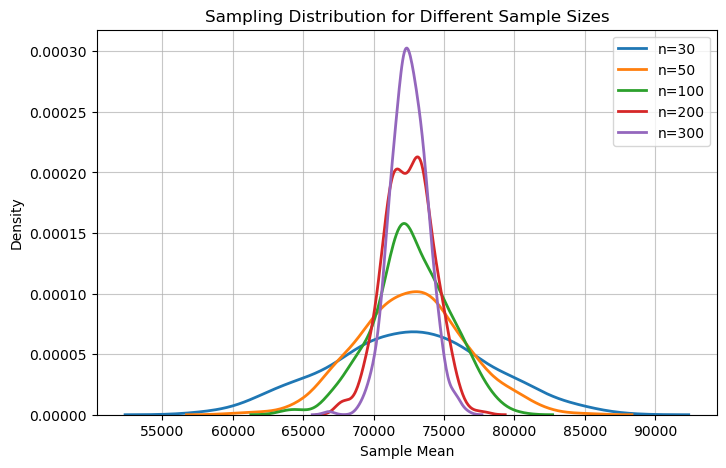

In [78]:
sizes = [30,50,100,200,300]

plt.figure(figsize=(8,5))

for n in sizes:

    means = []

    for i in range(400):
        sample = Employees.sample(n=n)
        means.append(sample["Monthly_Salary"].mean())

    
    sns.kdeplot(  means,linewidth=2,label=f"n={n}" )

plt.title("Sampling Distribution for Different Sample Sizes")

plt.xlabel("Sample Mean")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.7)

plt.show()